# LEVIR-CD — Load & Inspect

Goal: load the **LEVIR-CD** binary change-detection dataset and inspect it well enough to (a) confirm it can be fed to the vendored loader (`BasicDataset` in `model/vendor/rs_mamba_cd/utils/data_loading.py`) and (b) understand the statistics that will drive the training baseline.

**What the vendored loader expects** (see `CLAUDE.md`): three parallel directories `t1/`, `t2/`, `label/`, with **matching filenames** for each example (t1 image, t2 image, label share the same stem). Labels are binarized at load (`label[label != 0] = 1`); inputs are Albumentations-normalized.

**Two things to watch for during inspection:**
1. **Folder naming.** The canonical LEVIR-CD distribution ships `A/` (before), `B/` (after), `label/` under `train/`, `val/`, `test/` splits — *not* `t1/`/`t2/`. We detect this and map `A→t1`, `B→t2`.
2. **Tile size.** The original LEVIR-CD is **1024×1024** (637 pairs). The model's tiny config uses `image_size=256`, so the full-res set needs cropping (the vendored `crop_img` does this). A very common Kaggle redistribution (`LEVIR-CD256`) is *pre-cropped* to 256×256 — which is ready to use as-is. We report the actual on-disk size so we know which case we're in.

> Designed to run on Kaggle (Tesla T4), consistent with `environment_validation.ipynb`. The next cell **downloads the dataset in code via `kagglehub`** (`mdrifaturrahman33/levir-cd`) — no UI "Add Input" step needed. The only prerequisite is that the notebook has **Internet enabled** (Settings → Internet), which you already need for the git clone / pip installs. `DATA_ROOT` is then resolved from the kagglehub path automatically.

## 1. Configuration & dataset discovery

In [5]:
# Fetch LEVIR-CD via kagglehub — fully code-based, no UI 'Add Input' needed.
# Idempotent: returns the cached path immediately on re-runs. Requires Internet enabled
# in the notebook settings (already needed for the git clone / pip installs).
import kagglehub
from pathlib import Path

KAGGLE_HANDLE = "mdrifaturrahman33/levir-cd"
KAGGLEHUB_PATH = Path(kagglehub.dataset_download(KAGGLE_HANDLE))
print(f"kagglehub downloaded to: {KAGGLEHUB_PATH}")
for p in sorted(KAGGLEHUB_PATH.iterdir()):        # peek at top level (expect a 'LEVIR CD/' folder)
    print("  ", p.name + ("/" if p.is_dir() else ""))

kagglehub downloaded to: /kaggle/input/datasets/mdrifaturrahman33/levir-cd
   LEVIR CD/


In [6]:
from pathlib import Path
import os

# Where the LEVIR-CD dataset lives. Leave as None to resolve it from CANDIDATE_ROOTS / SEARCH_PATHS below;
# set it explicitly to short-circuit all discovery (e.g. DATA_ROOT = Path("/kaggle/input/levir-cd/LEVIR CD")).
DATA_ROOT: "Path | None" = None

# Known explicit locations, tried (in order) before any recursive search. KAGGLEHUB_PATH (from the
# download cell above) is preferred when present. Note: the dataset's top folder is 'LEVIR CD' (with a
# space). A UI 'Add Input' attach would instead mount at /kaggle/input/<slug>/ — we cover that too.
CANDIDATE_ROOTS = [
    *([KAGGLEHUB_PATH] if "KAGGLEHUB_PATH" in globals() else []),
    Path("/kaggle/input/levir-cd/LEVIR CD"),
    Path("/kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD"),
    Path("/kaggle/input/levir-cd"),
]

# Fallback only: recursively search these bases if no explicit candidate matches.
SEARCH_PATHS = [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("./data"),
    Path("."),
]

# Folder-name aliases: maps what's on disk -> the names the vendored loader expects.
T1_ALIASES = ("t1", "a")
T2_ALIASES = ("t2", "b")
LABEL_ALIASES = ("label", "labels", "gt", "mask")
SPLIT_NAMES = ("train", "val", "test")


def looks_like_image_dir(d: Path) -> bool:
    """Return True if directory `d` directly contains image files."""
    if not d.is_dir():
        return False
    exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
    return any(p.suffix.lower() in exts for p in d.iterdir() if p.is_file())


def has_triplet(d: Path) -> bool:
    """Return True if `d` directly holds a t1/a + t2/b + label triplet of subfolders."""
    try:
        names = {p.name.lower() for p in d.iterdir() if p.is_dir()}
    except (PermissionError, OSError):
        return False
    return (
        bool(names & set(T1_ALIASES))
        and bool(names & set(T2_ALIASES))
        and bool(names & set(LABEL_ALIASES))
    )


def find_dataset_root(search_paths: "list[Path]") -> "Path | None":
    """Find a dir that holds a t1/t2/label triplet, either directly or under train/val/test."""
    for base in search_paths:
        if not base.exists():
            continue
        try:
            candidates = [base, *sorted(base.rglob("*"))]
        except (PermissionError, OSError):
            candidates = [base]
        for d in candidates:
            if not d.is_dir():
                continue
            # Case A: split layout — base/<split>/{t1,t2,label}
            split_dirs = [d / s for s in SPLIT_NAMES if (d / s).is_dir()]
            if split_dirs and any(has_triplet(s) for s in split_dirs):
                return d
            # Case B: flat layout — base/{t1,t2,label}
            if has_triplet(d):
                return d
    return None


def dump_mounts(max_lines: int = 50) -> None:
    """Print what's actually mounted, so the real dataset path is visible when discovery fails."""
    for base in (Path("/kaggle/input"), Path("/kaggle/working")):
        print(f"\n=== {base} ===")
        if not base.exists():
            print("  (does not exist)")
            continue
        try:
            entries = sorted(base.rglob("*"))
        except (PermissionError, OSError) as e:
            print(f"  (could not list: {e})")
            continue
        if not entries:
            print("  (empty — the dataset is probably not attached to this notebook)")
            continue
        for p in entries[:max_lines]:
            print(f"  {'D' if p.is_dir() else 'f'} {p}")
        if len(entries) > max_lines:
            print(f"  ... (+{len(entries) - max_lines} more)")


if DATA_ROOT is None:
    # 1) Try the explicit candidates. Descend into each (in case the triplet sits one level deeper),
    #    falling back to the candidate itself if it already is the root.
    for cand in CANDIDATE_ROOTS:
        if cand.exists():
            DATA_ROOT = find_dataset_root([cand]) or cand
            print(f"Matched explicit candidate: {cand}")
            break

if DATA_ROOT is None:
    # 2) Last resort: recursive search.
    print("No explicit candidate matched; falling back to recursive search...")
    DATA_ROOT = find_dataset_root(SEARCH_PATHS)

if DATA_ROOT is None:
    print(
        "\n❌ Could not locate a LEVIR-CD root automatically. Here is what is actually mounted "
        "— find the folder whose train/test/val each contain A/B/label and set DATA_ROOT to it:"
    )
    dump_mounts()
    raise SystemExit(
        "DATA_ROOT not set. Copy the correct path from the listing above into DATA_ROOT at the top "
        "of this cell and re-run. If you skipped the kagglehub download cell above, run it first "
        "(or attach the dataset via 'Add Input' → search 'mdrifaturrahman33/levir-cd')."
    )

DATA_ROOT = Path(DATA_ROOT)
print(f"DATA_ROOT = {DATA_ROOT}")

Matched explicit candidate: /kaggle/input/datasets/mdrifaturrahman33/levir-cd
DATA_ROOT = /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD


In [7]:
# Print the directory tree (a couple of levels) so we can see the actual on-disk layout.
def print_tree(root: Path, max_depth: int = 2, _depth: int = 0) -> None:
    """Print a shallow directory tree under `root`, marking image-bearing dirs with file counts."""
    if _depth > max_depth:
        return
    entries = sorted([p for p in root.iterdir()], key=lambda p: (p.is_file(), p.name))
    for p in entries:
        indent = "    " * _depth
        if p.is_dir():
            n_imgs = sum(1 for f in p.iterdir() if f.is_file()) if looks_like_image_dir(p) else 0
            tag = f"  [{n_imgs} files]" if n_imgs else ""
            print(f"{indent}{p.name}/{tag}")
            if not n_imgs:  # only recurse into structural dirs, not image dirs
                print_tree(p, max_depth, _depth + 1)


print_tree(DATA_ROOT)

test/
    A/  [128 files]
    B/  [128 files]
    label/  [128 files]
train/
    A/  [445 files]
    B/  [445 files]
    label/  [445 files]
val/
    A/  [64 files]
    B/  [64 files]
    label/  [64 files]


## 2. Resolve the t1 / t2 / label directories per split

Normalise whatever layout we found into a uniform mapping `split -> {t1, t2, label}` of `Path`s, applying the `A→t1` / `B→t2` aliasing. If the dataset has no split subfolders, we treat the whole thing as a single pseudo-split called `all`.

In [8]:
def resolve_triplet(d: Path) -> "dict[str, Path] | None":
    """Given a directory, return {'t1','t2','label'} -> Path using the alias lists, or None."""
    subdirs = {p.name.lower(): p for p in d.iterdir() if p.is_dir()}

    def pick(aliases: "tuple[str, ...]") -> "Path | None":
        for a in aliases:
            if a in subdirs:
                return subdirs[a]
        return None

    t1, t2, label = pick(T1_ALIASES), pick(T2_ALIASES), pick(LABEL_ALIASES)
    if t1 and t2 and label:
        return {"t1": t1, "t2": t2, "label": label}
    return None


splits: "dict[str, dict[str, Path]]" = {}

# Split layout?
for s in SPLIT_NAMES:
    sd = DATA_ROOT / s
    if sd.is_dir():
        triplet = resolve_triplet(sd)
        if triplet:
            splits[s] = triplet

# Otherwise, flat layout.
if not splits:
    triplet = resolve_triplet(DATA_ROOT)
    if triplet:
        splits["all"] = triplet

assert splits, "Found a root but could not resolve t1/t2/label directories inside it."

for s, t in splits.items():
    print(f"[{s}]")
    for role, path in t.items():
        print(f"    {role:5s} -> {path}")

[train]
    t1    -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/train/A
    t2    -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/train/B
    label -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/train/label
[val]
    t1    -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/val/A
    t2    -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/val/B
    label -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/val/label
[test]
    t1    -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/test/A
    t2    -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/test/B
    label -> /kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD/test/label


## 3. File counts & filename correspondence

The loader pairs t1/t2/label purely by **matching filename stems** and `assert`s they line up. Here we check, per split, that the three directories hold the same set of stems — surfacing any mismatch *before* it blows up mid-training.

In [9]:
def stems(d: Path) -> "set[str]":
    """Return the set of filename stems (no extension) of non-hidden files in `d`."""
    return {f.stem for f in d.iterdir() if f.is_file() and not f.name.startswith(".")}


total = 0
for s, t in splits.items():
    s_t1, s_t2, s_lab = stems(t["t1"]), stems(t["t2"]), stems(t["label"])
    common = s_t1 & s_t2 & s_lab
    total += len(common)
    print(f"[{s}] t1={len(s_t1)}  t2={len(s_t2)}  label={len(s_lab)}  matched={len(common)}")
    only_t1 = s_t1 - (s_t2 & s_lab)
    only_t2 = s_t2 - (s_t1 & s_lab)
    only_lab = s_lab - (s_t1 & s_t2)
    for role, miss in (("t1", only_t1), ("t2", only_t2), ("label", only_lab)):
        if miss:
            sample = sorted(miss)[:5]
            print(f"    ⚠ {len(miss)} stems present only in {role} (no full triplet), e.g. {sample}")

print(f"\nTotal matched triplets across all splits: {total}")
print("(Original LEVIR-CD = 637 pairs @ 1024px; LEVIR-CD256 ≈ 10192 train / 1024 val / 2048 test patches @ 256px.)")

[train] t1=445  t2=445  label=445  matched=445
[val] t1=64  t2=64  label=64  matched=64
[test] t1=128  t2=128  label=128  matched=128

Total matched triplets across all splits: 637
(Original LEVIR-CD = 637 pairs @ 1024px; LEVIR-CD256 ≈ 10192 train / 1024 val / 2048 test patches @ 256px.)


## 4. Per-sample properties: size, dtype, channels, label values

Inspect one concrete triplet in detail. This tells us the tile size (1024 vs 256 — i.e. whether cropping is needed), the image mode/dtype the loader will see, and crucially that **labels are 2-valued** so the `label[label != 0] = 1` binarization is a no-op / correct.

In [10]:
import numpy as np
from PIL import Image


def describe_image(path: Path) -> dict:
    """Open an image and return a dict of its basic array properties."""
    img = Image.open(path)
    arr = np.array(img)
    return {
        "name": path.name,
        "pil_mode": img.mode,
        "size_wh": img.size,
        "shape": arr.shape,
        "dtype": str(arr.dtype),
        "min": int(arr.min()),
        "max": int(arr.max()),
        "unique": np.unique(arr)[:10].tolist(),
    }


# Pick the first split that has data, and the first matched stem within it.
probe_split = next(iter(splits))
t = splits[probe_split]
common = sorted(stems(t["t1"]) & stems(t["t2"]) & stems(t["label"]))
stem = common[0]


def find_by_stem(d: Path, stem: str) -> Path:
    """Return the single file in `d` whose stem matches `stem`."""
    matches = list(d.glob(stem + ".*"))
    assert len(matches) == 1, f"Expected exactly one match for {stem} in {d}, got {matches}"
    return matches[0]


print(f"Probing split '{probe_split}', stem '{stem}':\n")
for role in ("t1", "t2", "label"):
    info = describe_image(find_by_stem(t[role], stem))
    print(f"  {role:5s}: {info}")

Probing split 'train', stem 'train_1':

  t1   : {'name': 'train_1.png', 'pil_mode': 'RGB', 'size_wh': (1024, 1024), 'shape': (1024, 1024, 3), 'dtype': 'uint8', 'min': 0, 'max': 255, 'unique': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}
  t2   : {'name': 'train_1.png', 'pil_mode': 'RGB', 'size_wh': (1024, 1024), 'shape': (1024, 1024, 3), 'dtype': 'uint8', 'min': 0, 'max': 255, 'unique': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}
  label: {'name': 'train_1.png', 'pil_mode': 'L', 'size_wh': (1024, 1024), 'shape': (1024, 1024), 'dtype': 'uint8', 'min': 0, 'max': 255, 'unique': [0, 255]}


## 5. Visualise a few triplets

Eyeball t1 / t2 / label side by side, plus a change overlay (red = changed pixels on top of t2). This is the quickest way to confirm the label genuinely corresponds to the before/after pair and that `A`/`B` weren't swapped relative to the label.

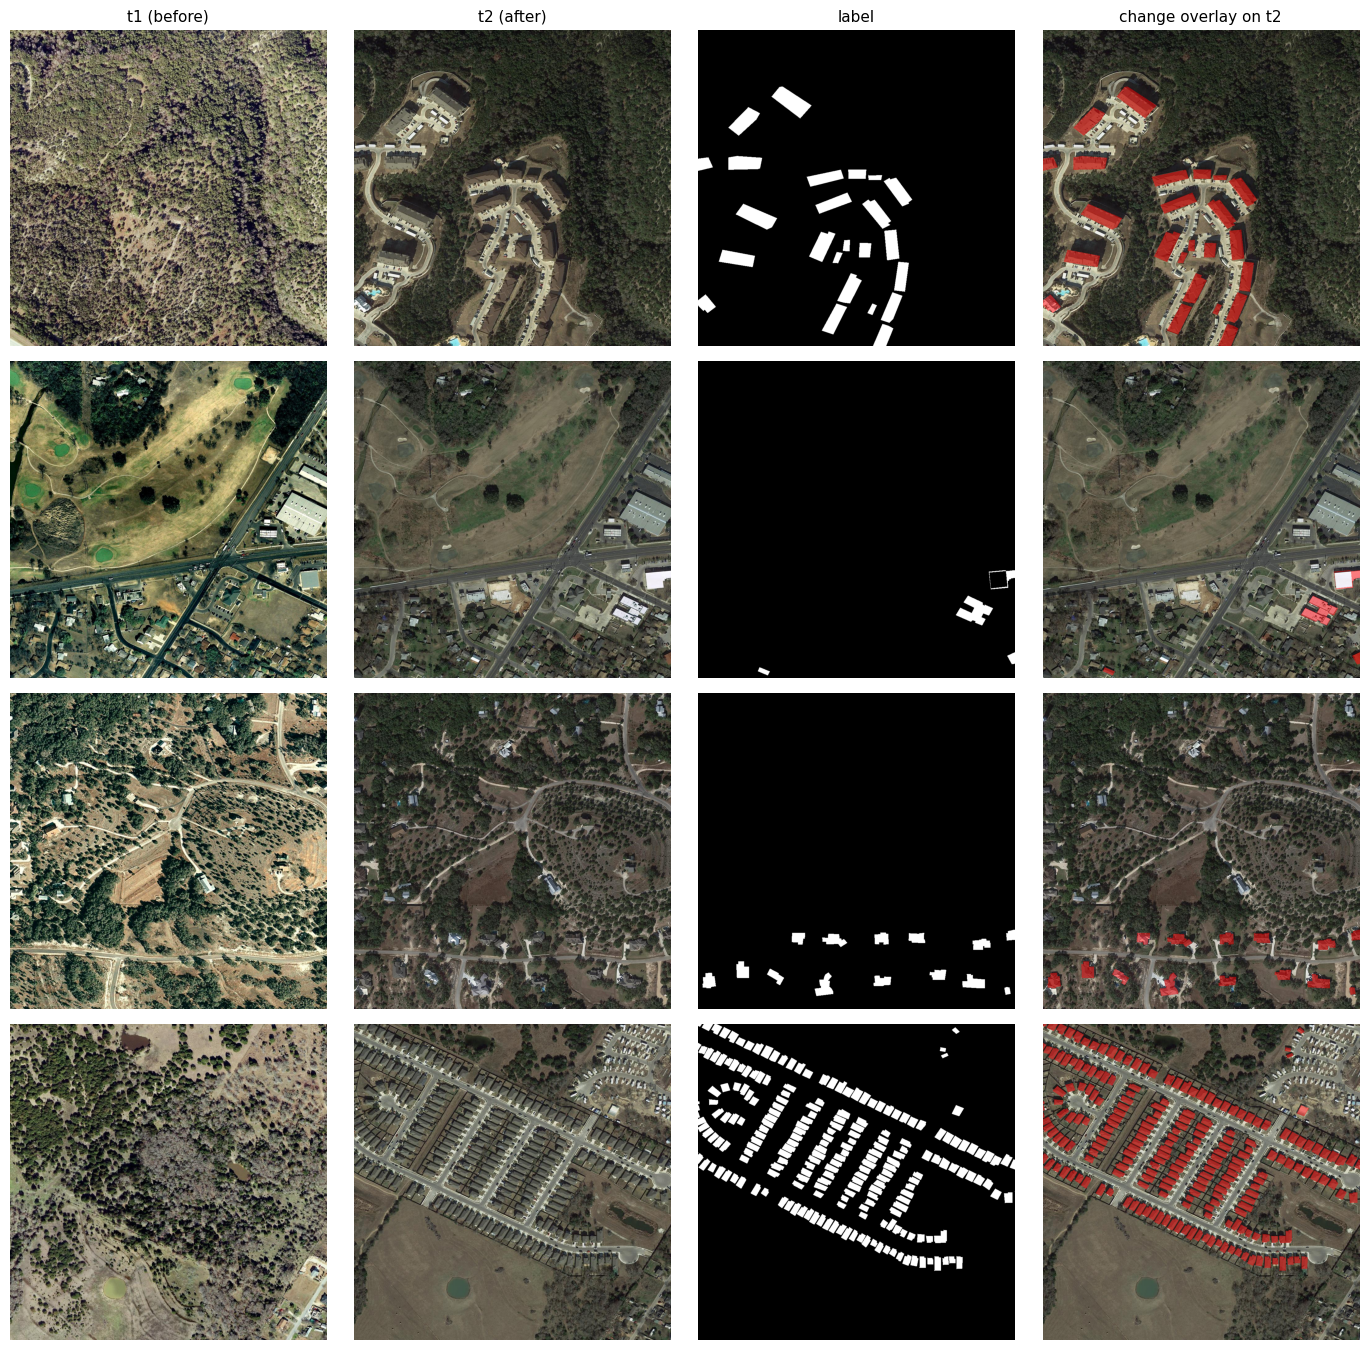

In [11]:
import random
import matplotlib.pyplot as plt

random.seed(0)
N_SHOW = 4
sample_stems = random.sample(common, min(N_SHOW, len(common)))

fig, axes = plt.subplots(len(sample_stems), 4, figsize=(14, 3.4 * len(sample_stems)))
if len(sample_stems) == 1:
    axes = axes[None, :]
col_titles = ["t1 (before)", "t2 (after)", "label", "change overlay on t2"]

for r, st in enumerate(sample_stems):
    im1 = np.array(Image.open(find_by_stem(t["t1"], st)).convert("RGB"))
    im2 = np.array(Image.open(find_by_stem(t["t2"], st)).convert("RGB"))
    lab = np.array(Image.open(find_by_stem(t["label"], st)).convert("L"))
    mask = lab != 0

    overlay = im2.copy()
    overlay[mask] = (0.5 * overlay[mask] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

    for c, img in enumerate([im1, im2, lab, overlay]):
        ax = axes[r, c]
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_axis_off()
        if r == 0:
            ax.set_title(col_titles[c], fontsize=11)
    axes[r, 0].set_ylabel(st, fontsize=9)

plt.tight_layout()
plt.show()

## 6. Class balance — change-pixel statistics

Change detection is heavily **foreground-imbalanced** (most pixels are unchanged). The fraction of positive (changed) pixels matters directly for choosing the loss (the vendored pipeline uses a Dice+BCE-style combo) and for reading early training curves sanely. We scan the labels and summarise the positive ratio.

In [12]:
from tqdm.auto import tqdm

# Cap the scan for speed on the large 256-patch redistributions; raise/remove to scan everything.
MAX_LABELS_PER_SPLIT = 2000

ratios_by_split: "dict[str, np.ndarray]" = {}
for s, t in splits.items():
    lab_stems = sorted(stems(t["label"]))
    if len(lab_stems) > MAX_LABELS_PER_SPLIT:
        lab_stems = random.sample(lab_stems, MAX_LABELS_PER_SPLIT)
    ratios = []
    empties = 0
    for st in tqdm(lab_stems, desc=f"scanning labels [{s}]", leave=False):
        lab = np.array(Image.open(find_by_stem(t["label"], st)).convert("L"))
        pos = float((lab != 0).mean())
        ratios.append(pos)
        if pos == 0.0:
            empties += 1
    ratios = np.array(ratios)
    ratios_by_split[s] = ratios
    print(
        f"[{s}] n={len(ratios)}  mean changed={ratios.mean():.4%}  "
        f"median={np.median(ratios):.4%}  max={ratios.max():.4%}  "
        f"all-negative tiles={empties} ({empties / len(ratios):.1%})"
    )

scanning labels [train]:   0%|          | 0/445 [00:00<?, ?it/s]

[train] n=445  mean changed=4.5890%  median=2.5953%  max=24.8340%  all-negative tiles=47 (10.6%)


scanning labels [val]:   0%|          | 0/64 [00:00<?, ?it/s]

[val] n=64  mean changed=4.1966%  median=3.1027%  max=20.3801%  all-negative tiles=8 (12.5%)


scanning labels [test]:   0%|          | 0/128 [00:00<?, ?it/s]

[test] n=128  mean changed=5.0943%  median=3.7349%  max=25.1315%  all-negative tiles=10 (7.8%)


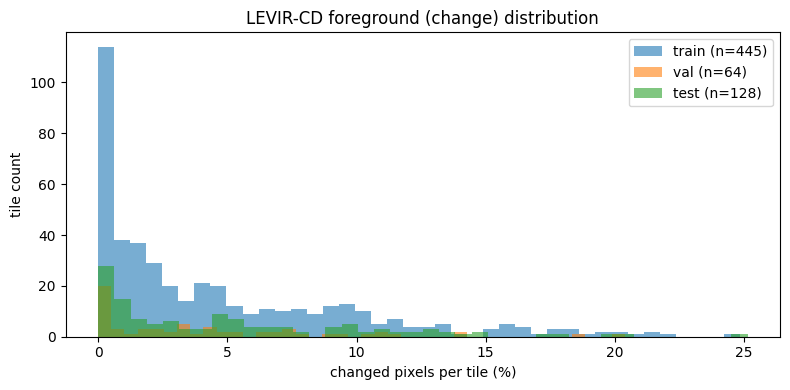

In [13]:
# Distribution of per-tile changed-pixel fraction.
fig, ax = plt.subplots(figsize=(8, 4))
for s, ratios in ratios_by_split.items():
    ax.hist(ratios * 100, bins=40, alpha=0.6, label=f"{s} (n={len(ratios)})")
ax.set_xlabel("changed pixels per tile (%)")
ax.set_ylabel("tile count")
ax.set_title("LEVIR-CD foreground (change) distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Tile-size consistency

The model's tiny config fixes `image_size=256`. Confirm every t1 image is square and report the distinct sizes present. If sizes are all 1024 we know the full-res set needs cropping before training; if all 256 it's ready to feed directly.

In [14]:
from collections import Counter

size_counts: Counter = Counter()
non_square = []
for s, t in splits.items():
    lab_stems = sorted(stems(t["t1"]))
    sample = lab_stems if len(lab_stems) <= 500 else random.sample(lab_stems, 500)
    for st in sample:
        w, h = Image.open(find_by_stem(t["t1"], st)).size
        size_counts[(w, h)] += 1
        if w != h:
            non_square.append((s, st, (w, h)))

print("t1 image sizes (w, h) -> count (sampled):")
for size, n in size_counts.most_common():
    print(f"    {size}: {n}")
if non_square:
    print(f"\n⚠ {len(non_square)} non-square images found, e.g. {non_square[:3]}")

MODEL_IMAGE_SIZE = 256
only_size = next(iter(size_counts)) if len(size_counts) == 1 else None
if only_size == (MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE):
    print(f"\n✓ All sampled tiles are {MODEL_IMAGE_SIZE}px — ready to feed the tiny config directly.")
elif only_size is not None:
    print(f"\n→ Tiles are {only_size}px but model expects {MODEL_IMAGE_SIZE}px — cropping needed "
          f"(see crop_img in utils/dataset_process.py).")

t1 image sizes (w, h) -> count (sampled):
    (1024, 1024): 637

→ Tiles are (1024, 1024)px but model expects 256px — cropping needed (see crop_img in utils/dataset_process.py).


## 8. Sanity check against the vendored `BasicDataset`

Finally, confirm the data flows through the *actual* loader the training pipeline will use. We point `BasicDataset` at one split's `t1/t2/label` dirs and pull a single item, checking tensor shapes, dtypes, and the Albumentations-normalized value ranges.

> Requires `albumentations` installed and the vendored code importable. If the dataset folders on disk are named `A`/`B` rather than `t1`/`t2`, we pass the resolved paths directly (the loader takes explicit dir paths, so the folder names don't have to be `t1`/`t2`).

In [15]:
import sys

# Point this at the vendored utils dir. On Kaggle, adjust to wherever the repo / vendor lives.
VENDOR_UTILS_CANDIDATES = [
    Path("../model/vendor/rs_mamba_cd/utils"),
    Path("/kaggle/working/mamba-rs-engine/model/vendor/rs_mamba_cd/utils"),
    Path("/kaggle/working/rs_mamba/change_detection_mamba/utils"),
]
vendor_utils = next((p for p in VENDOR_UTILS_CANDIDATES if (p / "data_loading.py").exists()), None)

if vendor_utils is None:
    print("⚠ Could not locate the vendored utils/data_loading.py — skipping the BasicDataset check.")
    print("  Set the path manually in VENDOR_UTILS_CANDIDATES to run it.")
else:
    sys.path.insert(0, str(vendor_utils.resolve()))
    from data_loading import BasicDataset

    s = "train" if "train" in splits else next(iter(splits))
    t = splits[s]
    ds = BasicDataset(str(t["t1"]), str(t["t2"]), str(t["label"]), train=True)
    print(f"BasicDataset('{s}') length: {len(ds)}")

    t1_tensor, t2_tensor, label_tensor, name = ds[0]
    print(f"\nSample name: {name}")
    print(f"t1   : shape={tuple(t1_tensor.shape)}  dtype={t1_tensor.dtype}  "
          f"range=({t1_tensor.min():.3f}, {t1_tensor.max():.3f})")
    print(f"t2   : shape={tuple(t2_tensor.shape)}  dtype={t2_tensor.dtype}  "
          f"range=({t2_tensor.min():.3f}, {t2_tensor.max():.3f})")
    print(f"label: shape={tuple(label_tensor.shape)}  dtype={label_tensor.dtype}  "
          f"unique={label_tensor.unique().tolist()}")
    print("\nExpected: t1/t2 -> (3, H, W) float, roughly zero-centred (ImageNet-normalized); "
          "label -> (H, W) with values {0, 1}.")

⚠ Could not locate the vendored utils/data_loading.py — skipping the BasicDataset check.
  Set the path manually in VENDOR_UTILS_CANDIDATES to run it.


## 9. Findings & next steps

_Fill in after running:_

- **Layout**: split / flat? folder names (`t1/t2` vs `A/B`)?
- **Counts**: matched triplets per split; any orphaned stems?
- **Tile size**: 1024px (needs `crop_img` → 256) or already 256px?
- **Labels**: confirmed 2-valued ({0, 255} → binarized to {0, 1})?
- **Class balance**: mean changed-pixel fraction; share of all-negative tiles — informs loss choice.
- **Loader**: `BasicDataset` returns the expected `(3,256,256)` / `(256,256)` tensors?

Once this checks out, the next milestone (per `CLAUDE.md`) is to stand up the PyTorch training baseline by adapting `model/vendor/rs_mamba_cd/train.py` + `utils/data_loading.py` on LEVIR-CD — which also becomes the throughput reference for the later TensorRT work.